In [2]:
import pandas as pd 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [14]:
data = pd.read_csv("german.data-numeric",header=None, sep = "\s+")
# data.columns = ["A" + str(i) for i in range(1, 26)]
# rename columns to A1, A2, ..., A25
data.columns = ["A" + str(i) for i in range(1, 26)]
data.shape

(1000, 25)

In [22]:
data['A25'] = data['A25'].apply(lambda x: 1 if x == 1 else 0)

label = data['A25']
features = data.drop(columns=['A25'])

X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 24), (200, 24), (800,), (200,))

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", dt.score(X_test, y_test))
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", rf.score(X_test, y_test))


Decision Tree Accuracy: 0.665
Random Forest Accuracy: 0.815


DT Accuracy without A1: 0.6950, RF Accuracy without A1: 0.7450
DT Accuracy without A2: 0.6700, RF Accuracy without A2: 0.7800
DT Accuracy without A3: 0.7250, RF Accuracy without A3: 0.7800
DT Accuracy without A4: 0.6750, RF Accuracy without A4: 0.7700
DT Accuracy without A5: 0.6800, RF Accuracy without A5: 0.7850
DT Accuracy without A6: 0.6450, RF Accuracy without A6: 0.7900
DT Accuracy without A7: 0.6450, RF Accuracy without A7: 0.8100
DT Accuracy without A8: 0.6650, RF Accuracy without A8: 0.7850
DT Accuracy without A9: 0.6400, RF Accuracy without A9: 0.7700
DT Accuracy without A10: 0.7350, RF Accuracy without A10: 0.8400
DT Accuracy without A11: 0.6500, RF Accuracy without A11: 0.8050
DT Accuracy without A12: 0.6850, RF Accuracy without A12: 0.8000
DT Accuracy without A13: 0.6850, RF Accuracy without A13: 0.7950
DT Accuracy without A14: 0.6450, RF Accuracy without A14: 0.7800
DT Accuracy without A15: 0.7150, RF Accuracy without A15: 0.8200
DT Accuracy without A16: 0.6850, RF Accurac

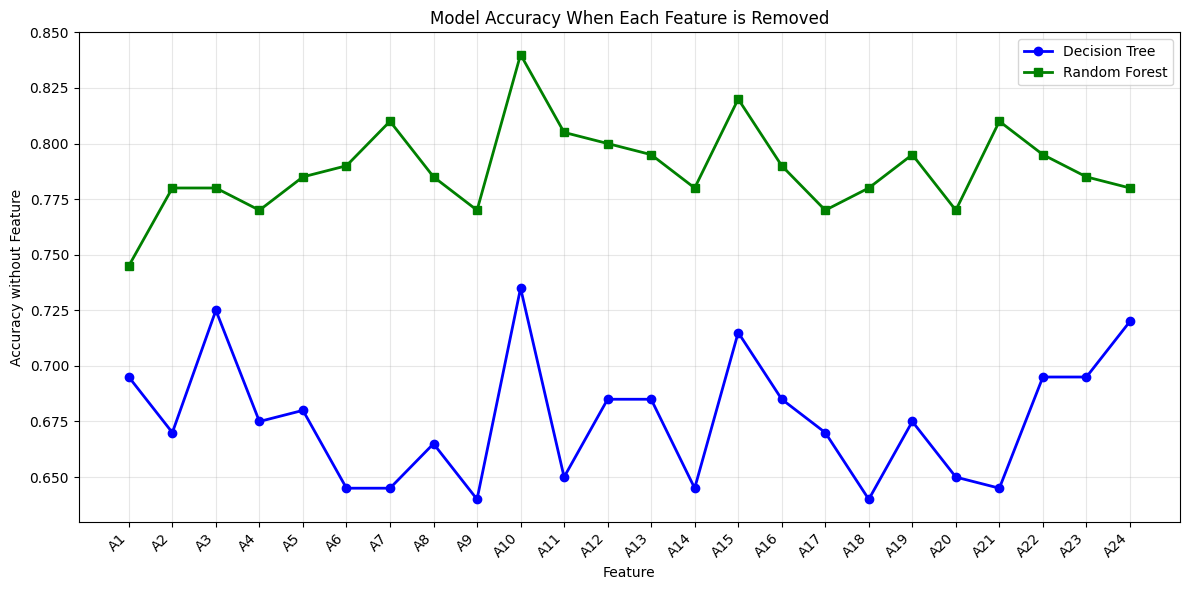

In [30]:
# Compare feature importance
# average accuracy without each feature and line chart for each feature accuracy without that feature
# the line connects the points for each feature accuracy without that feature

plt.figure(figsize=(12, 6))
dt_accuracies = []
rf_accuracies = []
features_list = []

for i in range(1, 25):
    X_ex_train = X_train.drop(columns=["A" + str(i)])
    X_ex_test = X_test.drop(columns=["A" + str(i)])
    
    dt_ex = DecisionTreeClassifier(random_state=42)
    dt_ex.fit(X_ex_train, y_train)
    dt_acc_ex = dt_ex.score(X_ex_test, y_test)
    dt_accuracies.append(dt_acc_ex)
    
    rf_ex = RandomForestClassifier(random_state=42)
    rf_ex.fit(X_ex_train, y_train)
    rf_acc_ex = rf_ex.score(X_ex_test, y_test)
    rf_accuracies.append(rf_acc_ex)
    
    features_list.append(i)
    print(f"DT Accuracy without A{i}: {dt_acc_ex:.4f}, RF Accuracy without A{i}: {rf_acc_ex:.4f}")

# Plot lines connecting the points for each feature
plt.plot(features_list, dt_accuracies, marker='o', color='blue', label='Decision Tree', linewidth=2)
plt.plot(features_list, rf_accuracies, marker='s', color='green', label='Random Forest', linewidth=2)

plt.xlabel("Feature")
plt.ylabel("Accuracy without Feature")
plt.title("Model Accuracy When Each Feature is Removed")

# Set x-axis ticks with feature names
feature_names = ["A" + str(i) for i in range(1, 25)]
plt.xticks(features_list, feature_names, rotation=45, ha='right')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
drop_columns = ['A10']
X_drop_train = X_train.drop(columns=drop_columns)
X_drop_test = X_test.drop(columns=drop_columns)
dt_drop = DecisionTreeClassifier(random_state=42)
dt_drop.fit(X_drop_train, y_train)
y_drop_pred_dt = dt_drop.predict(X_drop_test)
print("Decision Tree Accuracy after dropping A10 and A15:", dt_drop.score(X_drop_test, y_test))

# the same for random forest
rf_drop = RandomForestClassifier(random_state=42)
rf_drop.fit(X_drop_train, y_train)
y_drop_pred_rf = rf_drop.predict(X_drop_test)
print("Random Forest Accuracy after dropping A10 and A15:", rf_drop.score(X_drop_test, y_test))


Decision Tree Accuracy after dropping A10 and A15: 0.735
Random Forest Accuracy after dropping A10 and A15: 0.84


In [38]:
# try to drop 2 features
best_dt_acc = 0
drop_columns_for_dt = []
best_rf_acc = 0
drop_columns_for_rf = []

for feature_1 in range(1, 25):
    for feature_2 in range(feature_1 + 1, 25):
        drop_columns = ['A' + str(feature_1), 'A' + str(feature_2)]
        X_drop_train = X_train.drop(columns=drop_columns)
        X_drop_test = X_test.drop(columns=drop_columns)
        
        dt_drop = DecisionTreeClassifier(random_state=42)
        dt_drop.fit(X_drop_train, y_train)
        dt_acc_drop = dt_drop.score(X_drop_test, y_test)
        
        rf_drop = RandomForestClassifier(random_state=42)
        rf_drop.fit(X_drop_train, y_train)
        rf_acc_drop = rf_drop.score(X_drop_test, y_test)
        
        if dt_acc_drop > best_dt_acc:
            best_dt_acc = dt_acc_drop
            drop_columns_for_dt = drop_columns
        if rf_acc_drop > best_rf_acc:
            best_rf_acc = rf_acc_drop
            drop_columns_for_rf = drop_columns
        # print(f"DT Accuracy after dropping A{feature_1} and A{feature_2}: {dt_acc_drop:.4f}, RF Accuracy after dropping A{feature_1} and A{feature_2}: {rf_acc_drop:.4f}")

print(f"Best DT Accuracy: {best_dt_acc:.4f} with columns: {drop_columns_for_dt}")
print(f"Best RF Accuracy: {best_rf_acc:.4f} with columns: {drop_columns_for_rf}")

Best DT Accuracy: 0.7600 with columns: ['A5', 'A10']
Best RF Accuracy: 0.8200 with columns: ['A7', 'A14']


In [39]:
X_train = X_train.drop(columns = ['A10'])
X_test = X_test.drop(columns = ['A10'])
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Decision Tree Accuracy after dropping A10:", dt.score(X_test, y_test))
print("Random Forest Accuracy after dropping A10:", rf.score(X_test, y_test))

Decision Tree Accuracy after dropping A10: 0.735
Random Forest Accuracy after dropping A10: 0.84


In [52]:
from sklearn.model_selection import GridSearchCV

def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()

    
    classifier = GridSearchCV(estimator = model, param_grid=dict_param, n_jobs=n_jobs,cv = 2)
    classifier.fit(X_train, y_train)
    print('Best model: ', end = '')
    print(classifier.best_estimator_)
    # print('Best params: ', end = '')
    # print(classifier.best_params_)
    # print('Best score: ', end = '')
    # print(classifier.best_score_)
    return classifier.best_estimator_


In [53]:
 # Thử sử dụng GridSearchCV để khảo sát
from sympy import evaluate


dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)


Best model: DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=10)


In [54]:
best_tree.fit(X_train, y_train)
print("Best Decision Tree Accuracy:", best_tree.score(X_test, y_test))

Best Decision Tree Accuracy: 0.76


In [55]:
dict_param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_rf = grid_search('random-forest', n_jobs=-1, dict_param=dict_param_rf)

Best model: RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=50)


In [56]:
best_rf.fit(X_train, y_train)
print("Best Random Forest Accuracy:", best_rf.score(X_test, y_test))

Best Random Forest Accuracy: 0.79


In [49]:

print("Random Forest Accuracy after dropping A10:", rf.score(X_test, y_test))

Random Forest Accuracy after dropping A10: 0.84
